# End to end example of larger dataset

## Environment Setup

This notebook uses the `gstatsim-ex` conda environment. To create it from the provided `environment.yml`:

```
mamba env create -f environment.yml
conda activate gstatsim-ex
```

> **Note:** We recommend `mamba` over `conda` for faster dependency resolution and install.
> If you don't have `mamba` installed: `conda install -c conda-forge mamba`

In [1]:
from pathlib import Path
import tempfile

import earthaccess
import geopandas as gpd
import gstatsim as gs
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import pyogrio
import skgstat as skg
from skgstat import models
from sklearn.preprocessing import QuantileTransformer
from shapely import make_valid as shp_make_valid

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from plot_utils import splot2D

## Column Definitions

The HiCARS ice thickness files have a fixed 12-column schema documented in each
file's comment header. We define the column names here so they can be passed to
`read_icethk` at parse time — this lets us standardize naming across both IR1HI2
and IR2HI2 files, which use the same schema but slightly different header lengths.

Two names differ from the raw files:
- `THK` → `ICE_THICK`
- `PARTIAL_BED_REFLECT` → `BED_REFLECT`

In [2]:
COLUMNS = [
    "YEAR", "DOY", "SOD",
    "LON", "LAT",
    "ICE_THICK", "SRF_RNG", "BED_ELEVATION", "SURFACE_ELEVATION",
    "BED_REFLECT", "SRF_REFLECT", "AIRCRAFT_ROLL"
]

## Authentication

You will need a free NASA Earthdata account to download data. If you don't have one,
register at [urs.earthdata.nasa.gov](https://urs.earthdata.nasa.gov).

`earthaccess.login()` will prompt for your credentials interactively. To avoid
entering them each time, you can persist them to a `.netrc` file:

```python
earthaccess.login(persist=True)  # only needs to be run once
```

In [3]:
earthaccess.login()

Enter your Earthdata Login username:  roma8902
Enter your Earthdata password:  ········


## Reprojection and Projected Coordinates

The raw files store positions as longitude/latitude in **WGS-84 (EPSG:4326)**, but
geostatistical methods like kriging require a **projected coordinate system** where
distances are in meters rather than degrees.

We reproject to **Antarctic Polar Stereographic (EPSG:3031)**, which is the standard
projection for Antarctic data and minimizes distortion at high southern latitudes.

We also write the projected coordinates as explicit `X` and `Y` columns alongside
the geometry. This is because `gstatsim` expects a plain DataFrame with numeric
`X` and `Y` columns in meters — it doesn't know how to read from a geometry column
directly.

In [4]:
def build_geoparquet(input_dir: str | Path, out_path: str | Path):
    """
    Batch-convert a directory of IceBridge HiCARS ice thickness text files
    to a single GeoParquet file.

    Reads all ``*.txt`` files in ``input_dir``, concatenates them, drops
    rows with missing coordinates, and constructs point geometries from
    LON/LAT (EPSG:4326). The data is reprojected to Antarctic polar
    stereographic (EPSG:3031) and projected ``X``/``Y`` coordinates are
    written as explicit columns alongside the geometry for direct use
    with gstatsim.

    Parameters
    ----------
    input_dir : str or Path
        Directory containing ``*_icethk.txt`` files (IR1HI2 and/or IR2HI2).
    out_path : str or Path
        Destination path for the output GeoParquet file.

    Returns
    -------
    gpd.GeoDataFrame
        GeoDataFrame in EPSG:3031 with all input columns plus ``X``, ``Y``,
        ``source_file``, and ``instrument``.
    """
    input_dir = Path(input_dir)
    files = sorted(input_dir.glob("*.txt"))
    print(f"Found {len(files)} files")

    chunks = [read_icethk(f) for f in files]
    df = pd.concat(chunks, ignore_index=True)
    print(f"Total rows (including NaN positions): {len(df):,}")

    df = df.dropna(subset=["LON", "LAT"])
    print(f"Rows with valid positions: {len(df):,}")

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["LON"], df["LAT"]),
        crs="EPSG:4326",
    )

    gdf = gdf.to_crs("EPSG:3031")
    gdf["X"] = gdf.geometry.x
    gdf["Y"] = gdf.geometry.y

    gdf.to_parquet(out_path, compression="snappy")
    print(f"Written → {out_path}")
    return gdf

## Reading Individual Flight Line Files

Each granule downloaded from NSIDC is a single flight line — one `.txt` file per
aircraft transit. The files have a variable-length comment header (65 lines for
IR2HI2, 72 lines for IR1HI2) followed by space-delimited data.

`read_icethk` handles a single file: it detects the header length automatically
by scanning for the `Length_of_header` metadata field, parses the data block, and
tags each row with the source filename and instrument version (`HiCARS1` or `HiCARS2`)
for provenance tracking.

> **Note:** Rows with missing `LON`/`LAT` are retained at this stage — these occur
> at the start and end of flight lines where GPS lock was lost. They are dropped
> in `build_geoparquet` when we construct the point geometries.

In [5]:
def read_icethk(path: Path) -> pd.DataFrame:
    """
    Read a single IceBridge HiCARS ice thickness text file into a DataFrame.

    Parses the variable-length comment header by scanning for the
    ``Length_of_header`` metadata field, then reads the space-delimited
    data block. Missing values (``nan`` in the raw files) are preserved
    as ``NaN``. A ``source_file`` column and an ``instrument`` column
    (``HiCARS1`` or ``HiCARS2``, inferred from the filename prefix) are
    appended for provenance tracking.

    Parameters
    ----------
    path : Path
        Path to a ``*_icethk.txt`` file (IR1HI2 or IR2HI2 format).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: YEAR, DOY, SOD, LON, LAT, ICE_THICK,
        SRF_RNG, BED_ELEVATION, SURFACE_ELEVATION, BED_REFLECT,
        SRF_REFLECT, AIRCRAFT_ROLL, source_file, instrument.
        Rows with missing LON/LAT are retained at this stage.
    """
    with open(path) as f:
        for i, line in enumerate(f):
            if "Length_of_header:" in line:
                header_lines = int(line.split(":")[-1].strip().split()[0])
                break

    df = pd.read_csv(
        path,
        skiprows=header_lines,
        sep=r"\s+",
        names=COLUMNS,
        na_values="nan",
    )
    df["source_file"] = path.name
    df["instrument"] = "HiCARS1" if "IR1HI2" in path.name else "HiCARS2"
    return df

In [ ]:
out_path = Path("data/icethk_all.parquet").expanduser()
out_path.parent.mkdir(parents=True, exist_ok=True)

## Downloading IceBridge HiCARS Ice Thickness Data

We use [`earthaccess`](https://earthaccess.readthedocs.io/en/stable/) to search for and download 
granules from NASA Earthdata. `earthaccess` handles authentication and download in just a few lines 
of code — no manual file browsing required.

> **Finding a concept ID**  
> Each NASA Earthdata collection has a unique `concept_id` used to filter search results.  
> To find it, go to the dataset landing page (links below), click **"View data in Earthdata Search"**, 
> and copy the ID from the URL (e.g. `...?p=C3204979277-NSIDC_CPRD...`).  
> 
> Dataset landing pages:
> - [IR1HI2 — IceBridge HiCARS 1 L2 Ice Thickness](https://nsidc.org/data/ir1hi2/versions/1)
> - [IR2HI2 — IceBridge HiCARS 2 L2 Ice Thickness](https://nsidc.org/data/ir2hi2/versions/1)

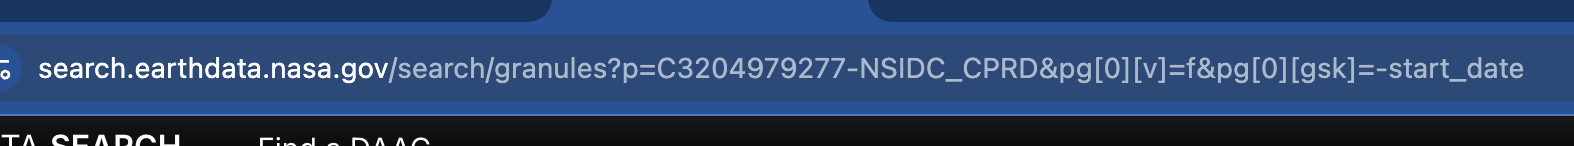

Full `search_data` parameter reference: [earthaccess docs](https://earthaccess.readthedocs.io/en/stable/api/#earthaccess.api.search_data)

## Download and Convert

This cell downloads 860 granules (~several GB) to a temporary directory and converts
them to a single GeoParquet. **This will take a while** depending
on your connection. The temp directory is cleaned up automatically after the parquet is written.

In [ ]:

with tempfile.TemporaryDirectory() as tmpdir:
    for concept_id in ["C3204979277-NSIDC_CPRD", "C3204982997-NSIDC_CPRD"]:
        results = earthaccess.search_data(concept_id=concept_id)
        print(f"{concept_id}: {len(results)} granules")
        earthaccess.download(results, local_path=tmpdir)
    gdf = build_geoparquet(tmpdir, out_path)

C3204979277-NSIDC_CPRD: 243 granules


QUEUEING TASKS | :   0%|          | 0/243 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/243 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/243 [00:00<?, ?it/s]

C3204982997-NSIDC_CPRD: 617 granules


QUEUEING TASKS | :   0%|          | 0/617 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/617 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/617 [00:00<?, ?it/s]

Found 860 files
Total rows (including NaN positions): 9,700,516
Rows with valid positions: 9,372,683
Written → ../data/icethk_all.parquet


## Load and plot data
Load in bed topography measurements from sample area. 

A few rows of the data are previewed using `.head()`

## TODO: Add more info here

In [19]:
datafile_path = Path("../data/icethk_all.parquet").expanduser()

gdf = gpd.read_parquet(datafile_path)

gdf.head()

,YEAR,DOY,SOD,LON,LAT,ICE_THICK,SRF_RNG,BED_ELEVATION,SURFACE_ELEVATION,BED_REFLECT,SRF_REFLECT,AIRCRAFT_ROLL,source_file,instrument,geometry,X,Y
531,2009,2,33057.5535,161.096539,-80.058225,532.63,1458.61,-520.62,-1458.61,-50.00,-21.90,11.11,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350801.917 -1024406.626),350801.916733,-1.024407e+06
532,2009,2,33057.8034,161.097043,-80.058075,532.42,1458.25,-520.06,12.36,-48.79,-17.63,11.09,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350798.224 -1024425.242),350798.223863,-1.024425e+06
533,2009,2,33058.0535,161.097547,-80.057925,NaN,1460.26,NaN,10.35,NaN,-16.40,11.08,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350794.531 -1024443.859),350794.530694,-1.024444e+06
534,2009,2,33058.3032,161.098051,-80.057774,NaN,1464.00,NaN,6.60,NaN,-19.77,10.98,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350790.873 -1024462.579),350790.872679,-1.024463e+06
535,2009,2,33058.5532,161.098556,-80.057624,NaN,1459.10,NaN,11.50,NaN,-14.17,10.64,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350787.161 -1024481.202),350787.161030,-1.024481e+06


# Select the field to plot

In [9]:
field = 'BED_REFLECT'

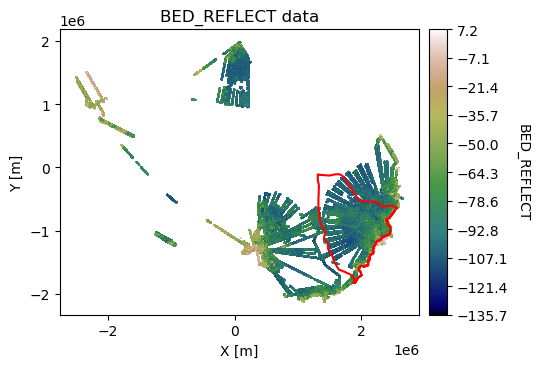

In [10]:
# plot data with WilkesLand boundary overlay
import pyogrio
from shapely import make_valid as shp_make_valid

# Read shapefile — force_2d and on_invalid="fix" to handle unclosed rings
wilkes = pyogrio.read_dataframe("../data/WilkesLand/WilkesLand.shp", force_2d=True, on_invalid="fix")
wilkes["geometry"] = wilkes.geometry.apply(shp_make_valid)
wilkes = wilkes.set_crs("EPSG:3031").to_crs(gdf.crs)

vmin = gdf[field].min()
vmax = gdf[field].max()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.scatter(gdf['X'], gdf['Y'], c=gdf[field], vmin=vmin, vmax=vmax,
                marker='.', s=0.5, cmap='gist_earth')
wilkes.boundary.plot(ax=ax, color='red', linewidth=1.5)
plt.title(f'{field} data')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.locator_params(nbins=5)
plt.axis('scaled')

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(vmin, vmax, 11), cax=cax)
cbar.set_label(field, rotation=270, labelpad=15)
plt.show()

In [11]:
# Clip data to WilkesLand boundary (wilkes already loaded and reprojected above)
gdf = gpd.clip(gdf, wilkes)
print(f"Points after clipping: {len(gdf)}")

Points after clipping: 3539604


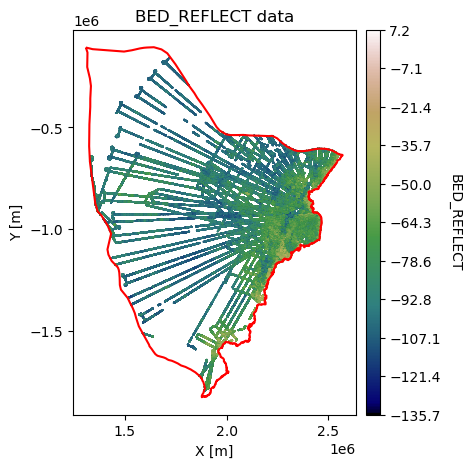

In [12]:
# Plot the clipped data
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.scatter(gdf['X'], gdf['Y'], c=gdf[field], vmin=vmin, vmax=vmax,
                marker='.', s=0.5, cmap='gist_earth')
wilkes.boundary.plot(ax=ax, color='red', linewidth=1.5)
plt.title(f'{field} data')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.locator_params(nbins=5)
plt.axis('scaled')

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(vmin, vmax, 11), cax=cax)
cbar.set_label(field, rotation=270, labelpad=15)
plt.show()

Grid data to the desired simulation resolution. This is important because the resolution of the data affects the spatial statistics. We recommend gridding the data to the resolution at which you will be performing the interpolation.

In [13]:
field = 'BED_REFLECT'
df_field = gdf[['X', 'Y', field]].copy()
df_field

,X,Y,BED_REFLECT
3257032,1.888603e+06,-1.794413e+06,NaN
3257031,1.888621e+06,-1.794400e+06,NaN
3257030,1.888640e+06,-1.794386e+06,NaN
3257029,1.888658e+06,-1.794373e+06,NaN
3257028,1.888676e+06,-1.794359e+06,-91.27
...,...,...,...
1144085,1.578696e+06,-3.033766e+05,NaN
1144089,1.578631e+06,-3.033765e+05,NaN
1144088,1.578647e+06,-3.033765e+05,NaN
1144087,1.578663e+06,-3.033765e+05,-107.18


Subsampled 35396 points from 3539604


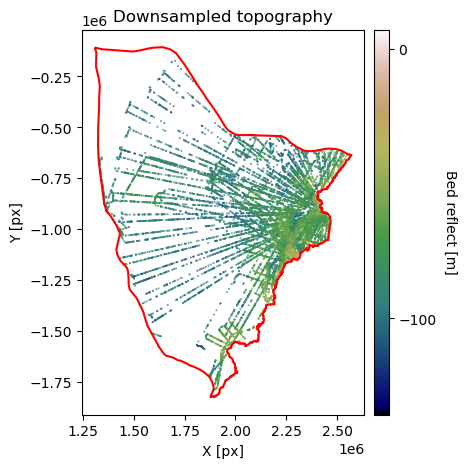

In [14]:
# Randomly downsample to x % of the dataset
df_sub = df_field.sample(frac=0.01, random_state=42)
print(f"Subsampled {len(df_sub)} points from {len(df_field)}")

# plot downsampled data
fig = plt.figure(figsize = (5,5))
ax = plt.gca()
im = ax.scatter(df_sub['X'], df_sub['Y'], c=df_sub['BED_REFLECT'], vmin=vmin, vmax=vmax,
                marker='.', s=0.5, cmap='gist_earth')
wilkes.boundary.plot(ax=ax, color='red', linewidth=1.5)
plt.title('Downsampled topography')
plt.xlabel('X [px]'); plt.ylabel('Y [px]')

# make color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-400, 600, 11), cax=cax)
cbar.set_label("Bed reflect [m]", rotation=270, labelpad=15)
plt.show()

## Compute normal score transformation
Many geostatistical methods require Gaussian assumptions, so we need to perform a normal score transformation to convert to a standard Gaussian distribution (mean = 0, standard deviaton = 1, Gaussian shape). After performing a geostatistical analysis such as kriging, the data is back-transformed to it's original distribution.

In [15]:
# normal score transformation
data = df_sub['BED_REFLECT'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution='normal').fit(data)
df_sub['BED_REFLECT'] = nst_trans.transform(data) 

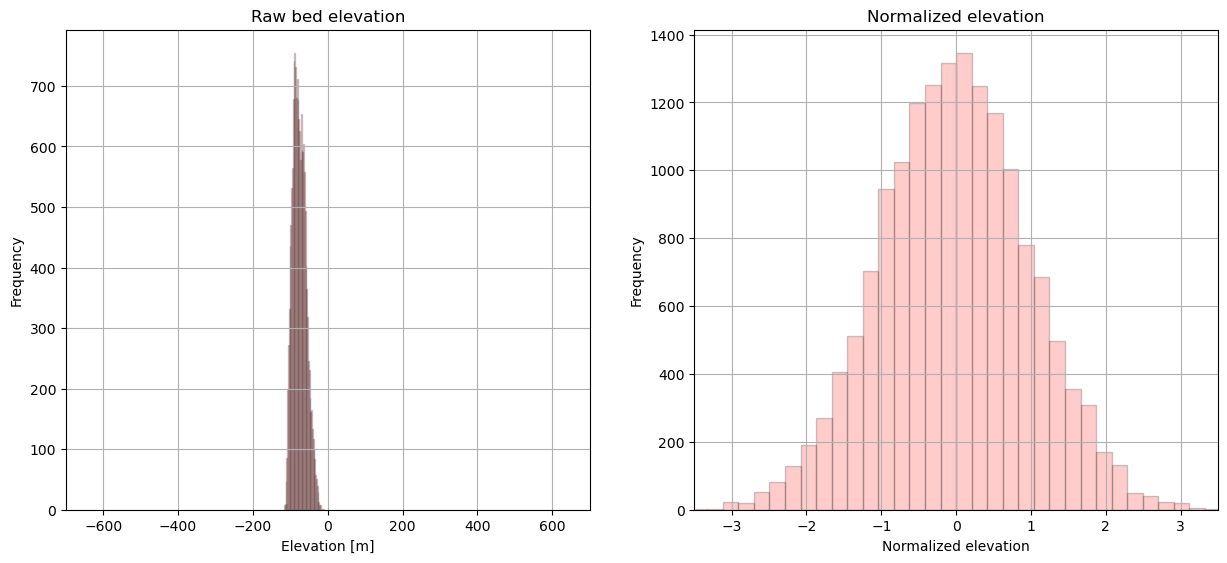

In [16]:
# plot original bed histogram
plt.subplot(121)
plt.hist(data, facecolor='red', bins=50, alpha=0.2, edgecolor='black')
plt.xlim([-700,700]); 
plt.xlabel('Elevation [m]'); plt.ylabel('Frequency'); plt.title('Raw bed elevation')
plt.grid(True)

# plot normal score bed histogram (with weights)
plt.subplot(122)
plt.hist(df_sub['BED_REFLECT'], facecolor='red', bins=50, alpha=0.2, edgecolor='black')
plt.xlim([-3.5,3.5]); 
plt.xlabel('Normalized elevation'); plt.ylabel('Frequency'); plt.title('Normalized elevation')
plt.grid(True)
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.8, top=1.0, wspace=0.2, hspace=0.3)
plt.show()

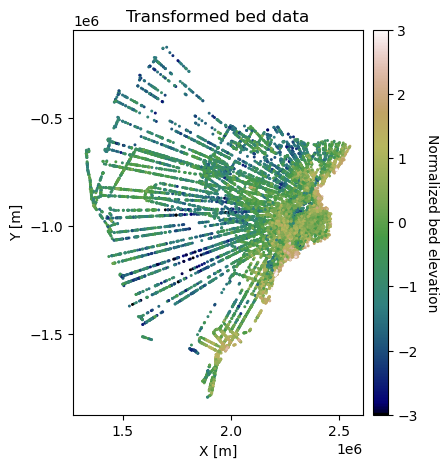

In [17]:
# plot transformed data
fig = plt.figure(figsize = (5,5))
ax = plt.gca()
im = ax.scatter(df_sub['X'], df_sub['Y'], c=df_sub['BED_REFLECT'], vmin=-3, vmax=3, 
                     marker='.', s=5, cmap='gist_earth')
plt.title('Transformed bed data')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.locator_params(nbins=5)
plt.axis('scaled')

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-3, 3, 7), cax=cax)
cbar.set_label("Normalized bed elevation", rotation=270, labelpad=15)
plt.show()

# Variogram Model  


Here we fit a variogram model to the experimental variogram calculated in the Experimental_Variogram example. Why fit a parametric variogram model to the experimental variogram? First of all, we need a way to interpolate variance estimates to all lag distances. Second, a variogram must satisfy certain mathematical properties in order to be used in kriging and stochastic simulation. This is covered in the Simple_Kriging.ipynb notebook.

The parameters of a variogram model are the nugget, sill, and range. The nugget or y-intercept represents small scale variability. Some of the nugget effect could be attributed to measurement error. The range is the lag distance where the variogram levels off. This means that two points separated by a lag distance greater than or equal to the range are not spatially correlated. The sill is the maximum variability between two points. When working with data that has been transformed to a standard Gaussian distribution, the sill is approximately 1. 


:::{figure}
<img src="./Images/variogram.png" class="bg-primary mb-1" width="500px">

Variogram schematic
:::

We use the SciKit-GStat package to model our variograms (see https://scikit-gstat.readthedocs.io/en/latest/ for more details).

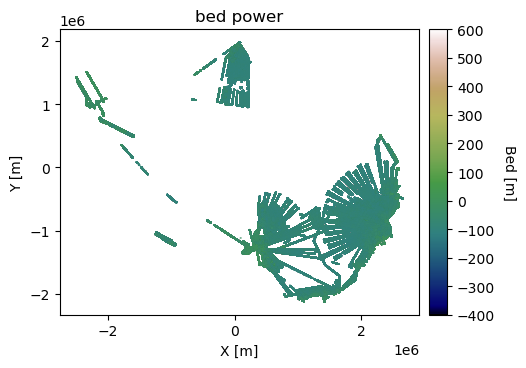

In [20]:
# importing icethk data 
gdf = gpd.read_parquet(datafile_path)
bpow = gdf[['X', 'Y', 'BED_REFLECT']]
splot2D(df=bpow, title='bed power', c='BED_REFLECT')

In [22]:
wilkes = pyogrio.read_dataframe("../data/WilkesLand/WilkesLand.shp", force_2d=True, on_invalid="fix")
wilkes["geometry"] = wilkes.geometry.apply(shp_make_valid)
wilkes = wilkes.set_crs("EPSG:3031").to_crs(gdf.crs)

In [23]:
#clipping to wilkesland
# Clip data to WilkesLand boundary (wilkes already loaded and reprojected above)
gdf = gpd.clip(gdf, wilkes)
print(f"Points after clipping: {len(gdf)}")

Points after clipping: 3539604


In [24]:
gdf=gdf.dropna()
print(f"Points after clipping: {len(gdf)}")

Points after clipping: 1590497


In [ ]:
splot2D(df=gdf, title='bed power', c='BED_REFLECT')

In [ ]:
#ok now randomly sampling 1% of my data to form the variogram which speeds it up for the purpose of this example

df_sample = gdf.sample(frac=0.01, random_state=42)

## Normal score transformation and experimental variogram

In [ ]:

# normal score transformation
data = df_sample['BED_REFLECT'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data)
df_sample['BED_REFLECT'] = nst_trans.transform(data) 

# compute experimental (isotropic) variogram
coords = df_sample[['X','Y']].values
values = df_sample['BED_REFLECT']
print(values)
maxlag = 50000          # maximum range distance
n_lags = 70             # num of bins

# compute variogram
V1 = skg.Variogram(coords, values, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)

# extract variogram values
xdata = V1.bins
ydata = V1.experimental

plt.figure(figsize=(6,4))
plt.scatter(xdata, ydata, s=12, c='g')
plt.title('Isotropoic Experimental Variogram')
plt.xlabel('Lag (m)'); plt.ylabel('Semivariance')  
plt.show()

## Fit variogram model

The variogram parameters are determined automatically using the SciKit-GStat functions:

In [ ]:
# use exponential variogram model
V1.model = 'matern' 
V1.parameters

These values are the range, sill, and nugget, respectively. The range describes the correlation length, or distance where two measurements are no longer correlated The sill is variance where the range is reached. The nugget is the variance at a lag distance of zero. 

The nugget effect is often attributed to measurement error (i.e., a non-zero nugget results from measurements with different values at the same location). We have a nugget of zero because our data is gridded. Depending on the analysis, it can be useful to work with non-gridded data in order to investigate the nugget effect and measurement uncertainty. For certain interpolation problems, it is best to have a nugget of zero, while sometimes it is useful to include the nugget.

Now we will create the variogram model. While there are many different variogram model types (see SCiKit-GStat documentation), GStatSim uses the exponential variogram model, which is the most widely used:

$$
\gamma(h) = b + (c - b)[1 - exp^{(-\frac{3h}{a})}]
$$


where $b$ is the nugget, $h$ is the lag distance, $c$ is the sill, and $a$ is the range. Note that the SCiKit-GStat variogram modeling defaults assign a nugget of 0.

In [ ]:
# set variogram parameters
vrange = V1.parameters[0]
vsill = V1.parameters[1]
vnugget = V1.parameters[2]

# evaluate models
xi = np.linspace(0, xdata[-1], 1000) 
y_exp = [models.matern(h, vrange, vsill, vnugget) for h in xi]

In [ ]:
# plot variogram model
plt.figure(figsize=(6,4))
plt.plot(xdata, ydata,'og', markersize=4, label='Experimental variogram')
plt.plot(xi, y_exp,'-', label='Modeled variogram')
plt.title('Isotropic variogram')
plt.xlabel('Lag [m]'); plt.ylabel('Semivariance')  
plt.legend(loc='upper left')
plt.show()

For anisotropic variograms, the variogram should be modeled in the major (smoothest) and minor (roughest) directions, which are typicaly orthogonal to each other.

Now that the variogram is modeled, we can use this information to perform interpolations.

Download the tutorial {Download}`here<./2_Variogram_model.ipynb>`.